# OpenCV Experiments

## AI Summer Internship 2026

### Assignment 4

**Submitted By:** Muhammad Saqlain

**BS Artificial Intelligence**

**The University of Faisalabad**

**Track 1: Computer Vision**

---

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Load Image

We use one sample image (`sample.jpg`) throughout the notebook. A synthetic image containing a triangle, rectangle, square, circle, and pentagon is included alongside this notebook so every experiment (including shape detection) works immediately with no setup.

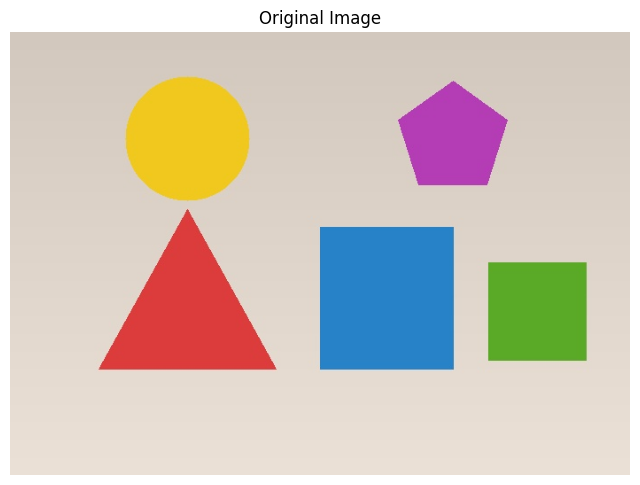

In [2]:
image = cv2.imread("sample.jpg")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Experiment 1 – Color Space Conversion

### Objective
Convert an RGB image into different color spaces.

### Theory
Color space conversion changes how color information is represented. Different color spaces are useful for different computer vision tasks.

Common color spaces:
- **RGB** – standard red/green/blue representation
- **Grayscale** – single intensity channel
- **HSV** – hue, saturation, value
- **LAB** – perceptually uniform color space

Grayscale reduces computation, while HSV is widely used for color segmentation.

### Code

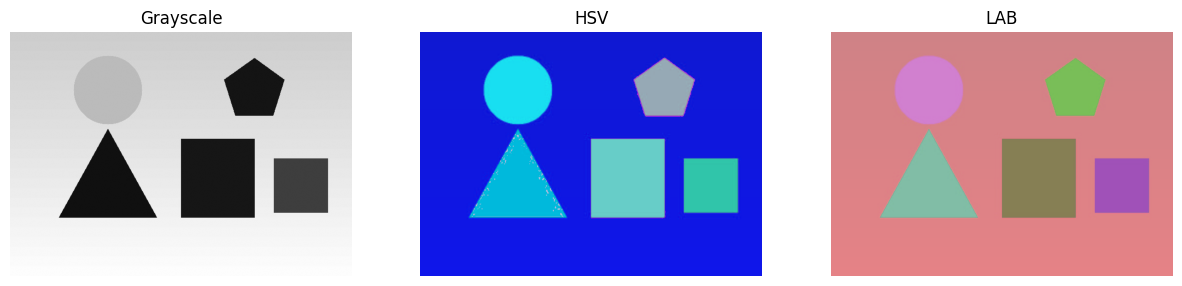

In [3]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(lab)
plt.title("LAB")
plt.axis("off")

plt.show()

### Explanation
- `cv2.cvtColor()` converts images between color spaces.
- Grayscale removes color information, keeping only intensity.
- HSV separates hue, saturation, and brightness, making color-based segmentation easier.
- LAB provides a perceptually uniform representation useful for image analysis.

### Conclusion
Different color spaces are suitable for different computer vision applications, and choosing the right one depends on the task at hand.

---

## Experiment 2 – Image Filtering

### Objective
Apply different filters to reduce image noise.

### Theory
Image filtering smooths images and removes unwanted noise. Three common filters are:
- **Gaussian Blur** – weighted averaging based on a Gaussian kernel
- **Median Blur** – replaces each pixel with the median of neighboring pixels
- **Bilateral Filter** – smooths the image while preserving edges

### Code

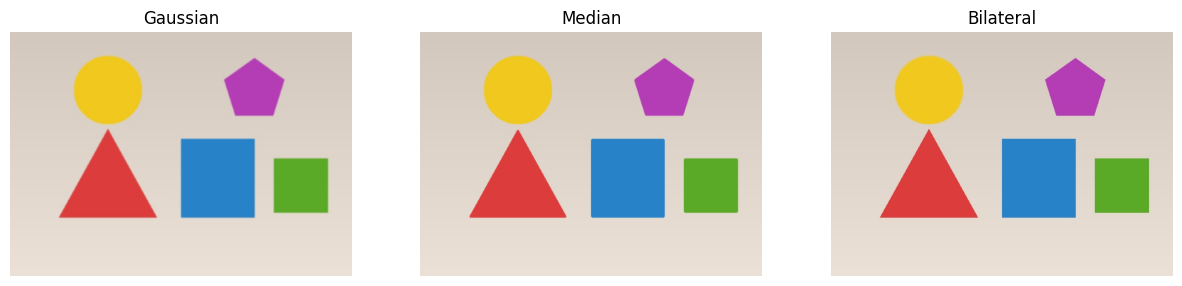

In [4]:
gaussian = cv2.GaussianBlur(image, (5,5), 0)

median = cv2.medianBlur(image, 5)

bilateral = cv2.bilateralFilter(image, 9, 75, 75)

titles = ["Gaussian", "Median", "Bilateral"]
images = [gaussian, median, bilateral]

plt.figure(figsize=(15,5))

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.show()

### Explanation
- Gaussian Blur smooths the image using a Gaussian kernel.
- Median Blur is effective at removing salt-and-pepper noise.
- Bilateral Filter smooths flat regions while preserving sharp edges.

### Conclusion
Filtering improves image quality and prepares images for later processing steps such as edge and contour detection.

---

## Experiment 3 – Edge Detection

### Objective
Detect edges using the Canny algorithm.

### Theory
Edges represent sudden intensity changes in an image and help identify object boundaries. The Canny algorithm uses gradient magnitude, non-maximum suppression, and hysteresis thresholding to produce clean, thin edges.

### Code

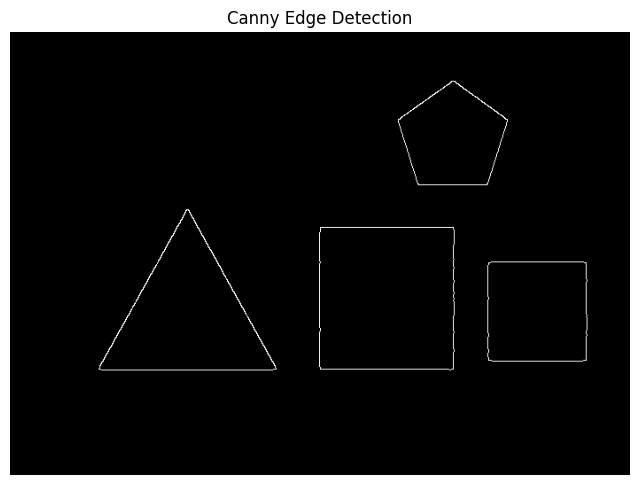

In [5]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

edges = cv2.Canny(blur, 100, 200)

plt.figure(figsize=(8,6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

### Explanation
Steps performed:
1. Convert the image to grayscale.
2. Remove noise using Gaussian blur.
3. Apply Canny edge detection with lower/upper hysteresis thresholds (100, 200).

### Conclusion
Canny detects object boundaries accurately while minimizing noise, making it a strong preprocessing step for contour and shape analysis.

---

## Experiment 4 – Contour Detection

### Objective
Detect contours of objects.

### Theory
Contours are curves joining continuous points along a boundary that share the same intensity. They are extremely useful for identifying object boundaries, measuring shapes, and object recognition.

### Code

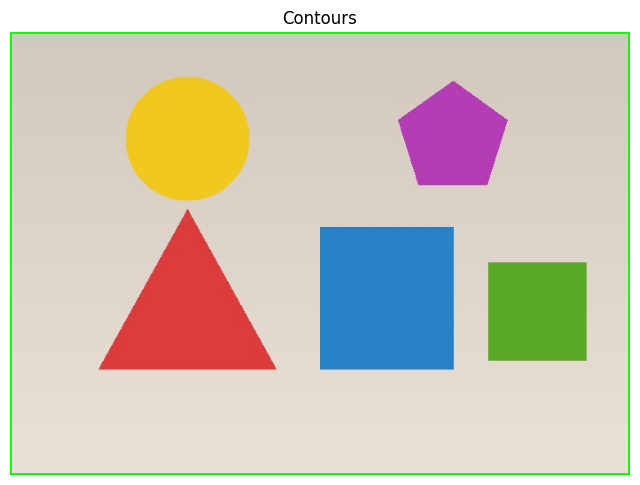

In [6]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

result = image.copy()

cv2.drawContours(
    result,
    contours,
    -1,
    (0,255,0),
    2
)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Contours")
plt.axis("off")
plt.show()

### Explanation
- `cv2.threshold()` converts the grayscale image to a binary image.
- `cv2.findContours()` detects the object boundaries in the binary image.
- `cv2.drawContours()` draws the detected contours on a copy of the original image.

### Conclusion
Contours are useful for object measurement, shape analysis, and recognition tasks.

---

## Experiment 5 – Shape Detection

### Objective
Detect basic geometric shapes.

### Theory
Polygon approximation (`cv2.approxPolyDP`) helps identify common shapes by counting the number of vertices in the approximated contour:
- 3 vertices → Triangle
- 4 vertices → Rectangle or Square
- More than 4 vertices → Circle or Polygon

### Code

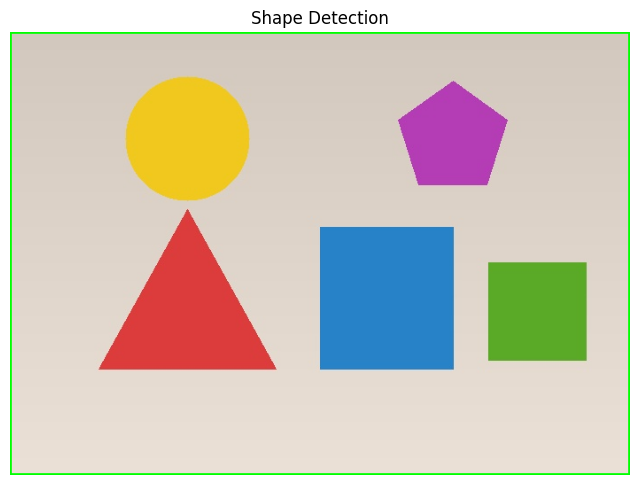

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

output = image.copy()

for contour in contours:

    epsilon = 0.02 * cv2.arcLength(contour, True)

    approx = cv2.approxPolyDP(contour, epsilon, True)

    if len(approx) == 3:
        shape = "Triangle"
    elif len(approx) == 4:
        shape = "Rectangle"
    else:
        shape = "Circle"

    x, y, w, h = cv2.boundingRect(approx)

    cv2.putText(
        output,
        shape,
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255,0,0),
        2
    )

    cv2.drawContours(
        output,
        [approx],
        -1,
        (0,255,0),
        2
    )

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Shape Detection")
plt.axis("off")
plt.show()

### Explanation
1. Detect contours in the binary image.
2. Approximate each contour to a polygon using `approxPolyDP`.
3. Count the number of vertices in the approximation.
4. Label the detected shape directly on the image.

### Conclusion
Shape detection enables recognition of simple geometric objects and forms the basis of many object recognition systems.

---

# Conclusion

In this notebook, five fundamental OpenCV experiments were performed:

1. Color Space Conversion
2. Image Filtering
3. Edge Detection
4. Contour Detection
5. Shape Detection

These experiments demonstrate the core image processing techniques used in computer vision systems. They improve image quality, extract useful features, detect object boundaries, and recognize geometric shapes. These techniques serve as the foundation for advanced applications such as object detection, face recognition, autonomous driving, and medical image analysis.